# Fast AI Agents with a Semantic Cache

In [1]:
# Warning control
import warnings
warnings.filterwarnings('ignore')

## Setup Environment

In [2]:
from cache.llm_evaluator import set_openai_key

set_openai_key()

In [3]:
import logging
import time
import json
import numpy as np
import pandas as pd
from datetime import datetime
from typing import List, Dict, Any, Optional

from langchain.schema import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END, START

import redis
from redisvl.utils.vectorize import HFTextVectorizer, OpenAITextVectorizer
from redisvl.extensions.cache.llm import SemanticCache
from redisvl.index import SearchIndex
from redisvl.query import VectorQuery

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger("agentic-workflow")

## Setup Redis Infra

In [4]:
redis_client = redis.Redis.from_url(
    "redis://localhost:6379", decode_responses=False
)
redis_client.ping()

True

### Build the Agent Knowledge Base (for RAG)


In [5]:
from agent import create_knowledge_base_from_texts


embeddings = OpenAITextVectorizer()

raw_docs = [
    "Our premium support plan includes 24/7 phone support, priority email response within 2 hours, and dedicated account management. Premium support costs $49/month.",
    "Account upgrade process: Go to Account Settings → Plan & Billing → Select Upgrade. Available plans: Basic $9/month, Pro $29/month, Enterprise $99/month.",
    "API rate limits by plan: Free tier 100 requests/hour, Basic 1,000 requests/hour, Pro 10,000 requests/hour, Enterprise unlimited with fair-use policy.",
    "Data export options: CSV, JSON, XML formats supported. Large exports (>1GB) may take up to 24 hours to process.",
    "Third-party integrations: Native support for Slack, Microsoft Teams, Zoom, Salesforce, HubSpot. 200+ additional integrations available via Zapier.",
    "Security features: SOC2 compliance, end-to-end encryption, GDPR compliance, SSO integration, audit logs, IP whitelisting.",
    "Billing and payments: We accept all major credit cards, PayPal, and ACH transfers. Enterprise customers can pay by invoice with NET30 terms.",
    "Account recovery: Use forgot password link, verify email, or contact support with account verification details. Response within 4 hours.",
]

success, message, kb_index = create_knowledge_base_from_texts(
    texts=raw_docs,
    source_id="customer_support_docs",
    redis_url="redis://localhost:6379",
    skip_chunking=True
)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:kb-utils:Using provided list of 8 text chunks
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:kb-utils:✅ Created knowledge base with 8 chunks (text_list)


### Build the Semantic Cache

In [6]:
from cache.wrapper import SemanticCacheWrapper
from cache.config import config
from cache.cross_encoder import CrossEncoder
from cache.faq_data_container import FAQDataContainer

cache = SemanticCacheWrapper.from_config(config)

data = FAQDataContainer()
cache.hydrate_from_df(data.faq_df, clear=True)

INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: mps
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: redis/langcache-embed-v1


✅ Redis is running and accessible!


INFO:redisvl.index.index:Index already exists, not overwriting.


Loaded 8 FAQ entries
Loaded 80 test queries


## Build the LangGraph Agent

In [7]:
from agent import (
    WorkflowState,
    initialize_agent,
    decompose_query_node,
    check_cache_node,
    research_node,
    evaluate_quality_node,
    synthesize_response_node,
    route_after_cache_check,
    route_after_quality_evaluation,
)

initialize_agent(cache, kb_index, embeddings)

In [10]:
workflow = StateGraph(WorkflowState)

# Add nodes 
workflow.add_node("decompose_query", decompose_query_node)
workflow.add_node("check_cache", check_cache_node)
workflow.add_node("research", research_node)
workflow.add_node("evaluate_quality", evaluate_quality_node)
workflow.add_node("synthesize", synthesize_response_node)

# Set entry point to decomposition node
workflow.set_entry_point("decompose_query")

# Add edges
workflow.add_edge("decompose_query", "check_cache")
workflow.add_conditional_edges(
    "check_cache",
    route_after_cache_check,
    {
        "research": "research",  # Go to research if cache misses
        "synthesize": "synthesize",  # Skip to synthesis if all cached
    },
)
workflow.add_edge("research", "evaluate_quality")
workflow.add_conditional_edges(
    "evaluate_quality",
    route_after_quality_evaluation,
    {
        "research": "research",
        "synthesize": "synthesize",
    },
)
workflow.add_edge("synthesize", END)

workflow_app = workflow.compile()

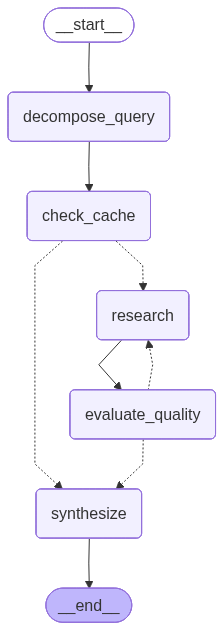

In [9]:
from IPython.display import Image, display

display(Image(workflow_app.get_graph().draw_mermaid_png()))

## Demo the Agent

<p style="background-color:#f7fff8; padding:15px; border-width:3px; border-color:#e0f0e0; border-style:solid; border-radius:6px"> 🚨
&nbsp; <b>Different Run Results:</b> The output visualizations generated may differ from those shown in the video.</p>

In [11]:
from agent import display_results
from agent import run_agent

### Scenario 1: Enterprise Platform Evaluation (cache building phase)


In [12]:
scenario1_query = """
I'm evaluating your platform for our enterprise needs. We need to understand your 
security and compliance standards including SOC2 status, want to know the API rate 
limits for the Pro plan since we're considering that tier, need details about 
Salesforce integration capabilities, and want to understand your payment options 
including whether you support ACH transfers.
"""

result1 = run_agent(workflow_app, scenario1_query)
display_results(result1)

INFO:agentic-workflow:================================================================================
INFO:agentic-workflow:🧠 Decomposing query...
INFO:agentic-workflow:🧠 Supervisor: Decomposing query: '
I'm evaluating your platform for our enterprise n...'
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:agentic-workflow:🧠 Decomposed into 4 sub-questions in 1604.82ms
INFO:agentic-workflow:   1. What are your security and compliance standards, including your current SOC2 status?
INFO:agentic-workflow:   2. What are the API rate limits for the Pro plan?
INFO:agentic-workflow:   3. What are your Salesforce integration capabilities?
INFO:agentic-workflow:   4. What payment options do you offer, and do you support ACH transfers?
INFO:agentic-workflow:🧠 Query decomposition complete
INFO:agentic-workflow:🔍 Supervisor: Checking cache for 4 sub-questions
INFO:agentic-workflow:   ❌ Cache MISS: 'What are your security and compliance st...'
INFO:age

\n🎯 SEMANTIC CACHING WORKFLOW ANALYSIS
📝 **Original Query:** 
I'm evaluating your platform for our enterprise needs. We need to understand your 
security and com...
🔄 **Execution Path:** decomposed → cache_checked → researched → quality_evaluated → synthesized
\n🧠 **Query Decomposition:** 4 sub-questions
   1. 🔍 **RESEARCH**: What are your security and compliance standards, including your current SOC2 status?
   2. 🔍 **RESEARCH**: What are the API rate limits for the Pro plan?
   3. 🔍 **RESEARCH**: What are your Salesforce integration capabilities?
   4. ✅ **CACHE HIT** (0.888): What payment options do you offer, and do you support ACH transfers?
\n📊 **Performance Metrics:**
   💾 Cache Hit Rate: **25.0%** (1/4 questions)
   🤖 LLM Calls: **8** (GPT-4: 2, GPT-4-Mini: 6)
   ⚡ Total Latency: **18736.92ms**
   ⏱️  Cache: 2086ms, Research: 7683ms
\n📋 **AI Response:**
--------------------------------------------------------------------------------


Thank you for considering our platform for your enterprise needs! I’m happy to provide a comprehensive overview addressing your questions about security, API limits, Salesforce integration, and payment options.

First, regarding security and compliance, we are SOC2 compliant and adhere to robust standards including end-to-end encryption, GDPR compliance, SSO integration, audit logs, and IP whitelisting. If you have specific security requirements or need more detailed documentation, please let us know—we’re happy to provide additional information.

For the Pro plan, the API rate limit is 10,000 requests per hour, which supports high-volume integrations and workflows.

In terms of Salesforce integration, we offer native support for Salesforce, enabling seamless connection and interaction with your Salesforce environment. Additionally, you can leverage over 200 other integrations through Zapier to further extend functionality. If you have particular use cases or need more technical details about the Salesforce integration, I’d be glad to assist.

As for payment options, we accept all major credit cards, PayPal, Apple Pay, Google Pay, and bank transfers (ACH) for orders over $100.

If you have any further questions or would like to discuss your specific requirements in more detail, please feel free to reach out. We’re here to help ensure our platform meets your enterprise needs!

--------------------------------------------------------------------------------


### Scenario 2: Implementation Planning (partial cache hits likely)

In [13]:
scenario2_query = """
We're moving forward with implementation planning. I need to compare API rate limits 
between Pro and Enterprise plans to decide on our tier, confirm the Salesforce 
integration capabilities we discussed, understand what data export options you provide 
for our migration needs, and verify the payment methods including ACH since our 
accounting team prefers that for monthly billing.
"""

result2 = run_agent(workflow_app, scenario2_query)
display_results(result2)

INFO:agentic-workflow:================================================================================
INFO:agentic-workflow:🧠 Decomposing query...
INFO:agentic-workflow:🧠 Supervisor: Decomposing query: '
We're moving forward with implementation planning...'
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:agentic-workflow:🧠 Decomposed into 4 sub-questions in 1187.68ms
INFO:agentic-workflow:   1. What are the API rate limits for the Pro and Enterprise plans?
INFO:agentic-workflow:   2. What Salesforce integration capabilities are available?
INFO:agentic-workflow:   3. What data export options are provided for migration purposes?
INFO:agentic-workflow:   4. What payment methods are supported, specifically is ACH available for monthly billing?
INFO:agentic-workflow:🧠 Query decomposition complete
INFO:agentic-workflow:🔍 Supervisor: Checking cache for 4 sub-questions
INFO:agentic-workflow:   ✅ Cache HIT: 'What are the API rate limits for the P

\n🎯 SEMANTIC CACHING WORKFLOW ANALYSIS
📝 **Original Query:** 
We're moving forward with implementation planning. I need to compare API rate limits 
between Pro a...
🔄 **Execution Path:** decomposed → cache_checked → researched → quality_evaluated → synthesized
\n🧠 **Query Decomposition:** 4 sub-questions
   1. ✅ **CACHE HIT** (0.947): What are the API rate limits for the Pro and Enterprise plans?
   2. ✅ **CACHE HIT** (0.924): What Salesforce integration capabilities are available?
   3. 🔍 **RESEARCH**: What data export options are provided for migration purposes?
   4. ✅ **CACHE HIT** (0.857): What payment methods are supported, specifically is ACH available for monthly billing?
\n📊 **Performance Metrics:**
   💾 Cache Hit Rate: **75.0%** (3/4 questions)
   🤖 LLM Calls: **4** (GPT-4: 2, GPT-4-Mini: 2)
   ⚡ Total Latency: **8945.66ms**
   ⏱️  Cache: 975ms, Research: 3117ms
\n📋 **AI Response:**
--------------------------------------------------------------------------------


Thank you for reaching out with your questions as you move forward with implementation planning. I’m happy to provide a comprehensive overview to help you make the best decision for your team.

For API rate limits, the Pro plan allows up to 10,000 requests per hour. If you anticipate higher usage or have specific needs, the Enterprise plan may offer increased limits—please let me know if you’d like more details on that.

Regarding Salesforce integration, we offer native support for Salesforce, enabling seamless connection and interaction with your data. Additionally, you can extend functionality further with over 200 other integrations available via Zapier. If you have particular workflows or use cases in mind, I’d be glad to provide more specific information about what’s possible.

For your migration needs, we support data exports in CSV, JSON, and XML formats. Please note that exports larger than 1GB may take up to 24 hours to process. If you need guidance on the export process or have special requirements, just let me know.

In terms of payment methods, we accept all major credit cards, PayPal, Apple Pay, Google Pay, and bank transfers (ACH) for orders over $100. This should align well with your accounting team’s preference for ACH on monthly billing.

If you need further details on any of these points or have additional questions, please don’t hesitate to ask. I’m here to help ensure a smooth transition and successful implementation!

--------------------------------------------------------------------------------


### Scenario 3: Pre-Purchase Comprehensive Review (many cache hits expected)

In [14]:
scenario3_query = """
Before finalizing our Pro plan purchase, I need complete validation on: your security 
compliance framework including SOC2 requirements, the exact API rate limits for the 
Pro plan we're purchasing, confirmation of the Salesforce integration features, all 
supported payment methods since we want to use ACH transfers, and your data export 
capabilities for our future migration planning.
"""

result3 = run_agent(workflow_app, scenario3_query)
display_results(result3)

INFO:agentic-workflow:================================================================================
INFO:agentic-workflow:🧠 Decomposing query...
INFO:agentic-workflow:🧠 Supervisor: Decomposing query: '
Before finalizing our Pro plan purchase, I need c...'
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:agentic-workflow:🧠 Decomposed into 4 sub-questions in 1312.01ms
INFO:agentic-workflow:   1. What is your security compliance framework, specifically regarding SOC2 requirements?
INFO:agentic-workflow:   2. What are the exact API rate limits for the Pro plan we are considering?
INFO:agentic-workflow:   3. What Salesforce integration features are included with the Pro plan?
INFO:agentic-workflow:   4. What payment methods do you support, and can we use ACH transfers?
INFO:agentic-workflow:🧠 Query decomposition complete
INFO:agentic-workflow:🔍 Supervisor: Checking cache for 4 sub-questions
INFO:agentic-workflow:   ✅ Cache HIT: 'What is your

\n🎯 SEMANTIC CACHING WORKFLOW ANALYSIS
📝 **Original Query:** 
Before finalizing our Pro plan purchase, I need complete validation on: your security 
compliance f...
🔄 **Execution Path:** decomposed → cache_checked → researched → quality_evaluated → synthesized
\n🧠 **Query Decomposition:** 4 sub-questions
   1. ✅ **CACHE HIT** (0.957): What is your security compliance framework, specifically regarding SOC2 requirements?
   2. ✅ **CACHE HIT** (0.971): What are the exact API rate limits for the Pro plan we are considering?
   3. 🔍 **RESEARCH**: What Salesforce integration features are included with the Pro plan?
   4. ✅ **CACHE HIT** (0.906): What payment methods do you support, and can we use ACH transfers?
\n📊 **Performance Metrics:**
   💾 Cache Hit Rate: **75.0%** (3/4 questions)
   🤖 LLM Calls: **4** (GPT-4: 2, GPT-4-Mini: 2)
   ⚡ Total Latency: **9378.49ms**
   ⏱️  Cache: 655ms, Research: 2068ms
\n📋 **AI Response:**
--------------------------------------------------------------------

Thank you for reaching out with your detailed questions before finalizing your Pro plan purchase. I’m happy to provide a comprehensive overview to help with your decision:

Security & Compliance: Our platform adheres to robust security and compliance standards, including SOC2 compliance, end-to-end encryption, GDPR compliance, SSO integration, audit logs, and IP whitelisting. If you require more detailed documentation or have specific security questions, please let us know—we’re happy to provide additional information.

API Rate Limits: With the Pro plan, you’ll have access to 10,000 API requests per hour. This should support most high-volume integration and automation needs.

Salesforce Integration: The Pro plan includes native Salesforce integration as part of our third-party integrations. You can connect Salesforce directly to our platform without needing additional middleware. The 10,000 API requests per hour limit also applies to Salesforce-related API usage, ensuring robust and reliable integration.

Payment Methods: We support all major credit cards, PayPal, Apple Pay, Google Pay, and bank transfers (ACH transfers) for orders over $100. You’ll be able to use ACH for your purchase.

Data Export Capabilities: Our platform offers comprehensive data export features, allowing you to export your data easily for migration or backup purposes. If you have specific requirements for data formats or export frequency, please let us know so we can confirm compatibility.

If you need further details on any of these points or have additional questions, please don’t hesitate to ask. We’re here to help ensure your onboarding process is smooth and fully meets your organization’s needs.

--------------------------------------------------------------------------------


## Agent Performance Analysis


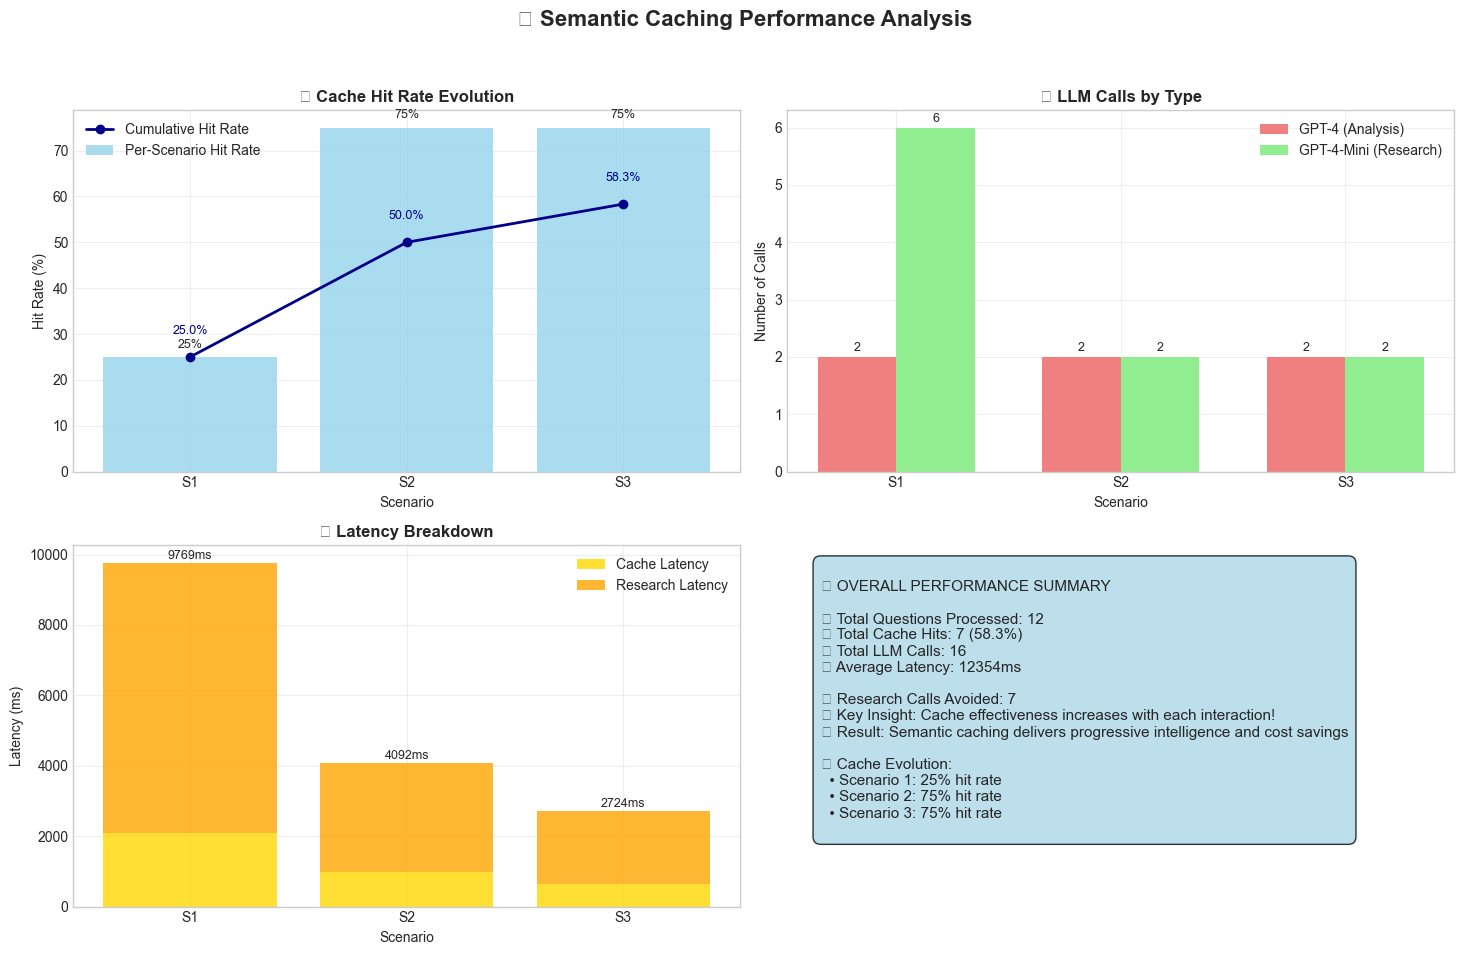

In [15]:
import warnings
warnings.simplefilter("ignore")

from agent import analyze_agent_results

total_questions, total_cache_hits = analyze_agent_results(
    [result1, result2, result3]
)

## Interactive Demo


Here is the link we used in the video for this section:
* https://att.com/international

In [16]:
from agent import launch_demo

launch_demo(
    workflow_app,
    cache,
    share=True,
    height=1500,
    inline=True
)

INFO:demo:Using Tavily API key from environment
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET http://127.0.0.1:7860/gradio_api/startup-events "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD http://127.0.0.1:7860/ "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.gradio.app/v3/tunnel-request "HTTP/1.1 200 OK"


* Running on local URL:  http://127.0.0.1:7860


INFO:httpx:HTTP Request: GET https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_darwin_arm64 "HTTP/1.1 200 OK"
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


* Running on public URL: https://6b8312aa31b520dd7a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


INFO:httpx:HTTP Request: HEAD https://6b8312aa31b520dd7a.gradio.live "HTTP/1.1 200 OK"


In [17]:
cache.cache.check(
    "checking cache", distance_threshold=1.0, num_results=100
)

[{'entry_id': '6951ac186c3c6207f25a11ebc9bd96c888b38fa33838cd138e1366e836a36ed7',
  'prompt': 'Where is my order?',
  'response': 'Use the tracking link sent to your email after shipping. Orders typically arrive within 2-7 business days depending on your location.',
  'vector_distance': 0.477180957794,
  'inserted_at': 1764449168.31,
  'updated_at': 1764449168.31,
  'key': 'semantic-cache:6951ac186c3c6207f25a11ebc9bd96c888b38fa33838cd138e1366e836a36ed7'},
 {'entry_id': '60fd55b8527fcd2bf427d81dc3f4c47c4bf8904c9802ffecbcf2c02b38f537ac',
  'prompt': 'How do I get a refund?',
  'response': 'To request a refund, visit your orders page and select **Request Refund**. Refunds are processed within 3-5 business days.',
  'vector_distance': 0.481174886227,
  'inserted_at': 1764449168.3,
  'updated_at': 1764449168.3,
  'key': 'semantic-cache:60fd55b8527fcd2bf427d81dc3f4c47c4bf8904c9802ffecbcf2c02b38f537ac'},
 {'entry_id': '7874cebc1fee0857ed3fc223829e2ff2e520bc96bb69a06d08a41b77e373eba3',
  'prom

In [18]:
cache.cache.clear()